Install Dependencies

In [1]:
#!pip install shapiq transformers matplotlib numpy
from __future__ import annotations

1. Define input text


In [2]:
text = "I really enjoy working with Shapley values in Python!"

2. Create the Sentiment Analysis Game for input text

In [3]:
from shapiq_games.benchmark.local_xai.benchmark_language import SentimentAnalysis

game = SentimentAnalysis(text, mask_strategy="mask")

print("Original text:", game.original_input_text)
print("Tokenized text:", game.input_text)
print("Number of players (tokens):", game.n_players)
print("Model output:", game.original_model_output)

tokens = game.input_text.split()
print(tokens)

/var/folders/z4/qt_tp8rs5gz63c5bp4cryrs00000gn/T/ipykernel_5791/2483046028.py:1: DeprecationWarning: This collection of games is deprecated and will be removed in a future version.
  from shapiq_games.benchmark.local_xai.benchmark_language import SentimentAnalysis


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Original text: I really enjoy working with Shapley values in Python!
Tokenized text: i really enjoy working with shapley values in python!
Number of players (tokens): 12
Model output: 0.9845684766769409
['i', 'really', 'enjoy', 'working', 'with', 'shapley', 'values', 'in', 'python!']


3. Compute Shapley values 

In [6]:
# simple exact computation (for small inputs)
from shapiq.game_theory.exact import ExactComputer

computer = ExactComputer(game)

# compute first-order Shapley values
iv = computer(index="SV")
print(iv)

InteractionValues(
    index=SV, max_order=1, min_order=0, estimated=False, estimation_budget=None,
    n_players=12, baseline_value=0.0,
    Top 10 interactions:
        (2,): 0.30065317362073846
        (1,): 0.14184866988383654
        (3,): 0.08977897807332169
        (4,): 0.08406928669752683
        (0,): 0.04644196009395077
        (8,): 0.03493703833820155
        (5,): 0.02583296851807343
        (9,): 0.021316101388067686
        (11,): -0.05123566103747074
        (10,): -0.27162845708849226
)


4. Visualize with sentence_plot

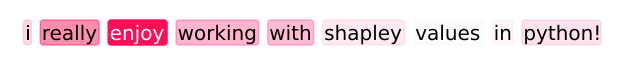

In [5]:
import matplotlib.pyplot as plt

from shapiq.plot.sentence import sentence_plot

fig, ax = sentence_plot(iv, tokens, chars_per_line=100, show=False)

plt.show()